# Enrichment supply scan — doc-side surfaces for injection

gold doc, or (inverted) a lane doc that becomes the row's grounding doc.
An injected surface must be copied from a document — the parent's
This notebook measures whether the materialized lane corpora actually
**contain** such surfaces, per **floor key** — the same units as the order
sheet, so demand (`data/composition/order_sheet.parquet`) and supply (this
scan) read against each other directly.

**Scope: structured identifiers only.** The other operator families are
corpus-free by design — markers (Decorate) and operator_syntax / length
(Rewrite / Expand) inherit parent qrels; corruptions are programmatic (R5).

**Method.** Per lane with `corpus.parquet` on disk: sample 1,500 docs
(seed 0), truncate each to its first 2,000 chars, run the regex banks, and
map fired banks to floor keys exactly as `composition/floors.py` does
(`*_like` → `id:shape_guess`, GENERAL-domain bank → `id:<bank>`, else
`id:<domain>`). A doc counts once per floor. Shares are estimates, not
censuses.

Re-run as wave corpora land — lanes are discovered from disk.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display
from tqdm.auto import tqdm

from query_taxonomy.banks import BANKS
from query_taxonomy.features import FeatureExtractor
from query_taxonomy.taxonomy import Domain, FeatureGroup


def show(df: pd.DataFrame) -> None:
    display(Markdown(df.to_markdown(index=False)))


SAMPLE_N = 1500          # per lane, seed 0 — an estimate, not a census
TRUNCATE_CHARS = 2000    # first chars of each doc fed to the banks

# bank name -> floor key, mirroring composition/floors.py::SpanFloorDeriver
_DOMAINS = {b().name.value: b().domain for b in BANKS}


def floor_key(bank_name: str) -> str:
    if bank_name.endswith("_like"):
        return "id:shape_guess"
    domain = _DOMAINS[bank_name]
    if domain is Domain.GENERAL:
        return f"id:{bank_name}"
    return f"id:{domain.value}"


extractor = FeatureExtractor()   # default engines: regex only — deterministic, cheap
lanes = sorted(p.parent.name for p in Path("data").glob("*/corpus.parquet"))
print(f"lane corpora on disk: {len(lanes)}")
print(", ".join(lanes))

lane corpora on disk: 12
crumb-code-retrieval, crumb-legal-qa, crumb-set-operation-entity-retrieval, crumb-stack-exchange, crumb-theorem-retrieval, limit, msmarco-passage-dev, nfcorpus, rarb-code, rarb-math, scifact, trec-dl-2022


## The scan

Per doc: which floors does it supply? A doc containing `10.0.0.1` and
`2024-01-01` supplies `id:network` and `id:datetime` — one count each,
however many spans fired. `doc_share` is the fraction of sampled docs
supplying the floor: the probability that a random gold doc from this lane
offers a copyable surface.

In [2]:
rows, bank_rows = [], []

for lane in lanes:
    corpus = pd.read_parquet(f"data/{lane}/corpus.parquet")
    docs = corpus.sample(n=min(SAMPLE_N, len(corpus)), random_state=0)
    texts = docs["text"].fillna("")
    if "title" in docs.columns:
        texts = docs["title"].fillna("") + "\n" + texts

    floor_hits: dict[str, int] = {}
    bank_hits: dict[str, int] = {}
    for text in tqdm(texts, desc=lane, leave=False):
        found = extractor.resolve(
            str(text)[:TRUNCATE_CHARS],
            groups=[FeatureGroup.STRUCTURED_IDENTIFIERS],
        ).spans.get(FeatureGroup.STRUCTURED_IDENTIFIERS, {})
        for bank in set(found):
            bank_hits[bank] = bank_hits.get(bank, 0) + 1
        for key in {floor_key(bank) for bank in found}:
            floor_hits[key] = floor_hits.get(key, 0) + 1

    n = len(docs)
    rows += [
        {"lane": lane, "floor": k, "doc_share": v / n, "docs": v, "sampled": n}
        for k, v in floor_hits.items()
    ]
    bank_rows += [
        {"lane": lane, "bank": b, "floor": floor_key(b), "doc_share": v / n}
        for b, v in bank_hits.items()
    ]
    top = sorted(floor_hits.items(), key=lambda kv: -kv[1])[:5]
    print(f"{lane:32s} n={n:>5,}  "
          + "  ".join(f"{k}={v / n * 100:.0f}%" for k, v in top))

supply = pd.DataFrame(rows)
bank_supply = pd.DataFrame(bank_rows)

crumb-code-retrieval             n=1,500  id:number=92%  id:tech=47%  id:shape_guess=14%  id:media=7%  id:finance=3%


crumb-legal-qa                   n=1,500  id:number=100%  id:shape_guess=56%  id:tech=46%  id:finance=27%  id:medical=8%


crumb-set-operation-entity-retrieval n=1,500  id:number=80%  id:shape_guess=33%  id:tech=15%  id:finance=7%  id:network=2%


crumb-stack-exchange             n=1,500  id:number=76%  id:shape_guess=62%  id:tech=57%  id:finance=11%  id:media=9%


crumb-theorem-retrieval          n=1,500  id:shape_guess=62%  id:number=54%  id:tech=38%  id:finance=15%  id:logistics=1%


...

nfcorpus                         n=1,500  id:number=86%  id:shape_guess=73%  id:tech=57%  id:finance=19%  id:network=2%


rarb-code                        n=1,500  id:tech=89%  id:number=37%  id:shape_guess=19%  id:media=8%  id:finance=5%


rarb-math                        n=1,500  id:number=100%  id:finance=51%  id:tech=16%  id:network=12%  id:shape_guess=10%


scifact                          n=1,500  id:shape_guess=82%  id:number=71%  id:tech=47%  id:finance=16%  id:network=3%


trec-dl-2022                     n=1,500  id:number=44%  id:shape_guess=27%  id:tech=15%  id:finance=9%  id:business_temporal=4%


## Readout — demand vs supply

Demand = the order sheet's `missing` (weight credit). Supply = doc share
per lane. Reading rule: a hungry floor is injection-feedable where a lane
shows material share — direct (parent, gold-doc) pairs live where the
parent's *own* gold doc carries the surface, and the d40(g) inversion
(any lane doc becomes the grounding doc) opens the whole column. A row of
near-zeros across all lanes = no injection supply anywhere → that floor
belongs to the synthetic lane.

In [3]:
sheet = pd.read_parquet("data/composition/order_sheet.parquet")
hungry = sheet[sheet["missing"] > 0]
hungry_id = hungry[hungry["floor"].str.startswith("id:")]
print("order-sheet demand (identifier floors):")
show(hungry_id[["slice", "floor", "amount", "credit", "missing", "reason"]])

pivot = (
    supply[supply["floor"].isin(hungry_id["floor"])]
    .pivot_table(index="floor", columns="lane", values="doc_share", fill_value=0.0)
    .reindex(hungry_id.sort_values("missing", ascending=False)["floor"])
    .fillna(0.0)
)
print(f"\nsupply: share of sampled docs with >=1 surface of the floor "
      f"(n={SAMPLE_N}/lane, %):")
show((pivot * 100).round(1).reset_index())

print("\nwhich banks carry each hungry floor (the concrete surfaces to copy):")
detail = (
    bank_supply[bank_supply["floor"].isin(hungry_id["floor"])]
    .groupby(["floor", "bank"])["doc_share"].max()
    .rename("best_lane_share")
    .reset_index()
    .sort_values(["floor", "best_lane_share"], ascending=[True, False])
)
show(detail[detail["best_lane_share"] > 0].groupby("floor").head(4).round(3))

full = (
    supply.pivot_table(index="floor", columns="lane", values="doc_share", fill_value=0.0)
    .sort_index()
)
print("\nfull identifier supply (context — every id floor the docs contain, %):")
show((full * 100).round(1).reset_index())

order-sheet demand (identifier floors):


| slice   | floor          |   amount |   credit |   missing | reason    |
|:--------|:---------------|---------:|---------:|----------:|:----------|
| A       | id:datetime    |     1000 |     3    |    997    | exhausted |
| A       | id:logistics   |     1000 |   109.5  |    890.5  | exhausted |
| A       | id:media       |     1000 |   124.25 |    875.75 | exhausted |
| A       | id:medical     |     1000 |     7.5  |    992.5  | exhausted |
| A       | id:network     |     1000 |   566.25 |    433.75 | capped    |
| A       | id:shape_guess |     1000 |   864.25 |    135.75 | exhausted |


supply: share of sampled docs with >=1 surface of the floor (n=1500/lane, %):


| floor          |   crumb-code-retrieval |   crumb-legal-qa |   crumb-set-operation-entity-retrieval |   crumb-stack-exchange |   crumb-theorem-retrieval |   limit |   msmarco-passage-dev |   nfcorpus |   rarb-code |   rarb-math |   scifact |   trec-dl-2022 |
|:---------------|-----------------------:|-----------------:|---------------------------------------:|-----------------------:|--------------------------:|--------:|----------------------:|-----------:|------------:|------------:|----------:|---------------:|
| id:datetime    |                    0   |              0   |                                    0.1 |                    2.7 |                       0.7 |     0   |                   0   |        0   |         0.5 |         0   |       0   |            0.7 |
| id:medical     |                    0.1 |              8   |                                    0.1 |                    1.5 |                       0   |     0   |                   0.4 |        0.9 |         0   |         0.3 |       2.5 |            1.9 |
| id:logistics   |                    0.7 |              6.3 |                                    0.3 |                    2.7 |                       1.1 |     0   |                   0.9 |        0.9 |         0.5 |         1.8 |       2.2 |            2.5 |
| id:media       |                    7.3 |              1.3 |                                    0.5 |                    8.7 |                       0.2 |     0   |                   0.4 |        1   |         7.6 |         0   |       1.1 |            0.3 |
| id:network     |                    1.1 |              4.5 |                                    1.8 |                    7.6 |                       0.1 |     0   |                   2.3 |        2.5 |         0.8 |        11.9 |       2.5 |            2   |
| id:shape_guess |                   13.6 |             55.7 |                                   33.5 |                   61.7 |                      61.7 |     4.9 |                  25.1 |       73.5 |        19.1 |         9.9 |      82   |           26.9 |


which banks carry each hungry floor (the concrete surfaces to copy):


| floor          | bank                     |   best_lane_share |
|:---------------|:-------------------------|------------------:|
| id:datetime    | datetime                 |             0.027 |
| id:logistics   | postal_code              |             0.063 |
| id:logistics   | sku                      |             0.016 |
| id:logistics   | phone_number             |             0.005 |
| id:logistics   | hazmat_code              |             0.003 |
| id:media       | social_handle            |             0.076 |
| id:media       | academic_identifier      |             0.02  |
| id:media       | astronomical_designation |             0.011 |
| id:media       | issn                     |             0.007 |
| id:medical     | genomic_accession        |             0.044 |
| id:medical     | medical_code             |             0.036 |
| id:medical     | clinical_trial_id        |             0.007 |
| id:medical     | hgvs_variant             |             0.001 |
| id:network     | http_status_code         |             0.119 |
| id:network     | host_port                |             0.029 |
| id:network     | email                    |             0.011 |
| id:network     | ip_address               |             0.01  |
| id:shape_guess | stock_ticker_like        |             0.798 |
| id:shape_guess | booking_reference_like   |             0.133 |
| id:shape_guess | derivatives_symbol_like  |             0.085 |
| id:shape_guess | error_code_like          |             0.047 |


full identifier supply (context — every id floor the docs contain, %):


| floor                |   crumb-code-retrieval |   crumb-legal-qa |   crumb-set-operation-entity-retrieval |   crumb-stack-exchange |   crumb-theorem-retrieval |   limit |   msmarco-passage-dev |   nfcorpus |   rarb-code |   rarb-math |   scifact |   trec-dl-2022 |
|:---------------------|-----------------------:|-----------------:|---------------------------------------:|-----------------------:|--------------------------:|--------:|----------------------:|-----------:|------------:|------------:|----------:|---------------:|
| id:business_temporal |                    0   |              0   |                                    0   |                    0.6 |                       0   |     0   |                   0   |        0   |         0   |         0   |       0   |            4.1 |
| id:datetime          |                    0   |              0   |                                    0.1 |                    2.7 |                       0.7 |     0   |                   0   |        0   |         0.5 |         0   |       0   |            0.7 |
| id:finance           |                    2.6 |             26.7 |                                    7.5 |                   10.9 |                      14.5 |     0   |                   9   |       19.1 |         4.8 |        50.8 |      16.3 |            8.7 |
| id:legal             |                    0   |              2.4 |                                    0   |                    0.1 |                       0   |     0   |                   0   |        0   |         0   |         0   |       0   |            0.1 |
| id:logistics         |                    0.7 |              6.3 |                                    0.3 |                    2.7 |                       1.1 |     0   |                   0.9 |        0.9 |         0.5 |         1.8 |       2.2 |            2.5 |
| id:media             |                    7.3 |              1.3 |                                    0.5 |                    8.7 |                       0.2 |     0   |                   0.4 |        1   |         7.6 |         0   |       1.1 |            0.3 |
| id:medical           |                    0.1 |              8   |                                    0.1 |                    1.5 |                       0   |     0   |                   0.4 |        0.9 |         0   |         0.3 |       2.5 |            1.9 |
| id:network           |                    1.1 |              4.5 |                                    1.8 |                    7.6 |                       0.1 |     0   |                   2.3 |        2.5 |         0.8 |        11.9 |       2.5 |            2   |
| id:number            |                   91.6 |            100   |                                   79.8 |                   75.9 |                      53.6 |     0   |                  52.9 |       85.6 |        37.4 |        99.9 |      71.3 |           44.4 |
| id:shape_guess       |                   13.6 |             55.7 |                                   33.5 |                   61.7 |                      61.7 |     4.9 |                  25.1 |       73.5 |        19.1 |         9.9 |      82   |           26.9 |
| id:tech              |                   47.3 |             45.9 |                                   15.5 |                   57.4 |                      37.9 |     5.2 |                  17.9 |       57.5 |        89.1 |        15.8 |      47.5 |           14.5 |

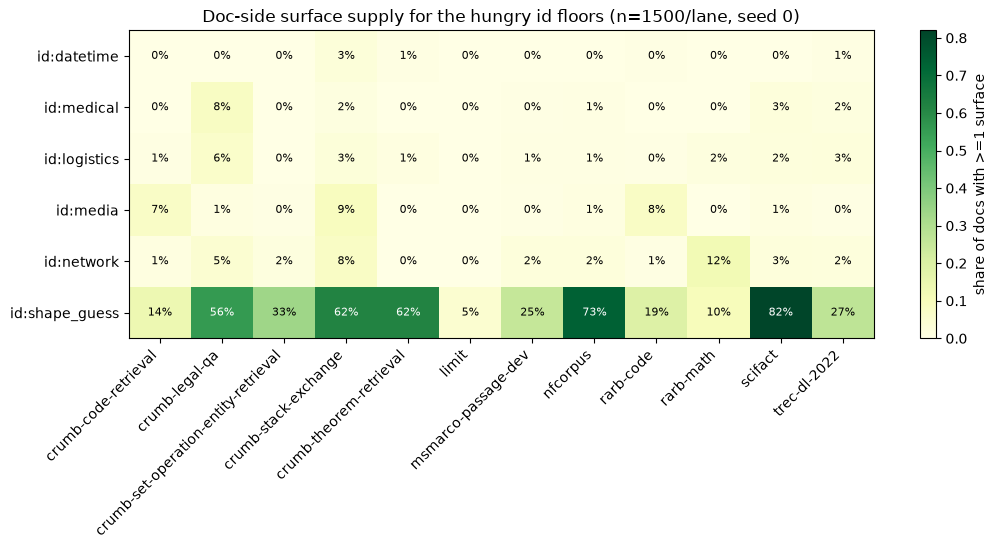

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(max(8, 0.9 * len(pivot.columns)), 0.6 * len(pivot) + 2)
)
im = ax.imshow(pivot.to_numpy(), cmap="YlGn", vmin=0, aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)), pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.iat[i, j]
        ax.text(j, i, f"{v * 100:.0f}%", ha="center", va="center",
                color="black" if v < 0.5 else "white", fontsize=8)
ax.set_title(
    f"Doc-side surface supply for the hungry id floors (n={SAMPLE_N}/lane, seed 0)"
)
fig.colorbar(im, ax=ax, label="share of docs with >=1 surface")
plt.tight_layout()
plt.show()